# MOVIELENS大作业

In [ ]:
%pip install seaborn plotly lightgbm
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

warnings.filterwarnings('ignore')

#读取评分数据
ratings = pd.read_csv('./ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'], 
    usecols=[0, 1, 2, 3], dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32', 'timestamp': 'int64'}, encoding='latin-1'
)

#读取用户信息
users = pd.read_csv('./users.csv', encoding='latin-1', usecols=['user_id', 'gender', 'zipcode', 'age_desc', 'occ_desc'])

#读取电影基本信息
movies = pd.read_csv('./movies.csv',  encoding='latin-1', usecols=['movie_id', 'title', 'genres'])

#读取电影详细信息并重命名列
movies_info = pd.read_csv('./info.csv',  encoding='latin-1', usecols=['id', 'name', 'genre','intro','directors','starts', 'release_time'])
movies_info.rename(columns ={ 'id':'movie_id', 'starts': 'stars'}, inplace = True)

Note: you may need to restart the kernel to use updated packages.


## 一、传统偏好发现

### checkpoint里已经给出的男女偏好分析部分略，下面为年龄偏好分析部分的实现

### 年龄偏好分析

In [71]:
#筛选观影人次>300的电影
popular = ratings['movie_id'].value_counts()
popular = popular[popular > 300]
popular = popular.rename('count')
popular = popular.rename_axis('movie_id')

#合并用户、评分、电影数据
merged_data = pd.merge(ratings[['user_id', 'movie_id', 'rating']], users[['user_id', 'age_desc']], on='user_id').merge(
    movies[['movie_id', 'title', 'genres']], on='movie_id')

#仅保留流行电影数据
filtered_data = merged_data[merged_data['movie_id'].isin(popular.index)]

In [72]:

def calculate_age_preference(age_group_name, global_mean_ref):
    #过滤当前年龄段数据
    group_data = filtered_data[filtered_data['age_desc'] == age_group_name]
    
    #计算组内平均分和观影次数
    group_mean = group_data.groupby('movie_id')['rating'].mean().rename('group_mean')
    n = group_data.groupby('movie_id').size().rename('n')
    
    #指标1：评分差异加权
    movie_global_mean = filtered_data.groupby('movie_id')['rating'].mean()
    delta_rating = (group_mean - movie_global_mean).rename('delta_rating')
    score1 = (delta_rating * np.log(n + 1)).rename('score1')  # +1防止log(0)
    
    #指标2：贝叶斯加权评分
    N_avg = n.mean()
    W = (0.5 * n / N_avg).clip(upper=1.0)
    bayesian_score = (W * group_mean + (1 - W) * global_mean_ref).rename('score2')
    
    #合并结果
    score_df = pd.concat([delta_rating, n, score1, bayesian_score], axis=1)
    return score_df.reset_index()

In [73]:
#获取所有age_desc分类
age_groups = filtered_data['age_desc'].unique().tolist()

#全局平均分用于贝叶斯计算
global_mean = filtered_data['rating'].mean()

for age_group in age_groups:
    #计算当前年龄组的偏好得分
    score_df = calculate_age_preference(age_group, global_mean)
    
    #合并电影信息
    result_df = score_df.merge(
        movies[['movie_id', 'title', 'genres']],
        on='movie_id'
    ).sort_values('score1', ascending=False)
    
    #展示Top10（评分差异指标）
    print(f"\n{age_group} 组偏好Top10（评分差异）")
    display(
        result_df.head(10)[['title', 'genres', 'score1', 'delta_rating', 'n']]
        .rename(columns={'score1': '偏好得分', 'delta_rating': '评分差异', 'n': '观影次数'})
        .reset_index(drop=True)
        .set_axis(pd.RangeIndex(1, 11), axis='index')
        .rename_axis('排名')
    )
    
    #展示Top10（贝叶斯指标）
    print(f"\n{age_group} 组偏好Top10（贝叶斯加权）")
    display(
        result_df.sort_values('score2', ascending=False)
        .head(10)[['title', 'genres', 'score2', 'n']]
        .rename(columns={'score2': '贝叶斯评分', 'n': '观影次数'})
        .reset_index(drop=True)
        .set_axis(pd.RangeIndex(1, 11), axis='index')
        .rename_axis('排名')
    )


Under 18 组偏好Top10（评分差异）


,title,genres,偏好得分,评分差异,观影次数
排名,,,,,
1,Robin Hood: Men in Tights (1993),Comedy,3.091307,1.069519,17.0
2,Billy Madison (1995),Comedy,2.773830,0.786598,33.0
3,Spaceballs (1987),Comedy|Sci-Fi,2.720807,0.742667,38.0
4,Snake Eyes (1998),Action|Crime|Mystery|Thriller,2.498800,0.946853,13.0
5,Pretty Woman (1990),Comedy|Romance,2.493027,0.832193,19.0
6,Pet Sematary (1989),Horror,2.458319,1.182201,7.0
7,Gremlins 2: The New Batch (1990),Comedy|Horror,2.426468,0.839500,17.0
8,Naked Gun 33 1/3: The Final Insult (1994),Comedy,2.403818,0.887656,14.0
9,"Piano, The (1993)",Drama|Romance,2.363462,1.075658,8.0



Under 18 组偏好Top10（贝叶斯加权）


,title,genres,贝叶斯评分,观影次数
排名,,,,
1,"Shawshank Redemption, The (1994)",Drama,4.543478,46.0
2,Pulp Fiction (1994),Crime|Drama,4.489796,49.0
3,"Godfather, The (1972)",Action|Crime|Drama,4.471698,53.0
4,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.464646,99.0
5,Good Will Hunting (1997),Drama,4.460813,39.0
6,Schindler's List (1993),Drama|War,4.446429,56.0
7,American Beauty (1999),Comedy|Drama,4.434783,92.0
8,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,4.430063,35.0
9,GoodFellas (1990),Crime|Drama,4.430038,25.0



56+ 组偏好Top10（评分差异）


...

,title,genres,贝叶斯评分,观影次数
排名,,,,
1,"Godfather, The (1972)",Action|Crime|Drama,4.541935,465
2,Schindler's List (1993),Drama|War,4.510345,435
3,"Shawshank Redemption, The (1994)",Drama,4.487500,400
4,Raiders of the Lost Ark (1981),Action|Adventure,4.475538,511
5,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,4.474227,291
6,"Sixth Sense, The (1999)",Thriller,4.457081,466
7,"Wizard of Oz, The (1939)",Adventure|Children's|Drama|Musical,4.446384,401
8,Casablanca (1942),Drama|Romance|War,4.438287,397
9,Rear Window (1954),Mystery|Thriller,4.416765,265



18-24 组偏好Top10（评分差异）


,title,genres,偏好得分,评分差异,观影次数
排名,,,,,
1,Spaceballs (1987),Comedy|Sci-Fi,3.106690,0.577463,216
2,Clue (1985),Comedy|Mystery,2.783057,0.566508,135
3,"Goonies, The (1985)",Adventure|Children's|Fantasy,2.660543,0.489635,228
4,Three Amigos! (1986),Comedy|Western,2.350953,0.477838,136
5,European Vacation (1985),Comedy,2.038619,0.458874,84
6,Rocky IV (1985),Action|Drama,1.937205,0.467570,62
7,"NeverEnding Story, The (1984)",Adventure|Children's|Fantasy,1.750647,0.325405,216
8,"Big Lebowski, The (1998)",Comedy|Crime|Mystery|Thriller,1.733553,0.312404,256
9,Happy Gilmore (1996),Comedy,1.731295,0.321533,217



18-24 组偏好Top10（贝叶斯加权）


,title,genres,贝叶斯评分,观影次数
排名,,,,
1,"Usual Suspects, The (1995)",Crime|Thriller,4.680798,401
2,"Shawshank Redemption, The (1994)",Drama,4.674569,464
3,American Beauty (1999),Comedy|Drama,4.521678,715
4,"Godfather, The (1972)",Action|Crime|Drama,4.505495,364
5,Schindler's List (1993),Drama|War,4.472851,442
6,Life Is Beautiful (La Vita Ã¨ bella) (1997),Comedy|Drama,4.466702,244
7,GoodFellas (1990),Crime|Drama,4.457912,297
8,"Matrix, The (1999)",Action|Sci-Fi|Thriller,4.446208,567
9,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War,4.442142,579


### 基于电影风格的年龄偏好可视化实现

数据预处理与类型展开

In [74]:
#展开电影类型为二进制列
movies_genres = pd.concat([movies['movie_id'], movies['genres'].str.get_dummies(sep='|').add_prefix('genre_')], axis=1)

#合并用户、评分、电影数据
full_data = pd.merge(filtered_data, movies_genres, on='movie_id',how='inner')

计算核心指标

In [75]:
#获取所有电影类型列表
genre_columns = [col for col in full_data.columns if col.startswith('genre_')]

#初始化结果容器
age_groups = full_data['age_desc'].unique()
genre_stats = []

#按年龄组和类型逐个计算指标
for age_group in age_groups:
    group_data = full_data[full_data['age_desc'] == age_group]
    
    for genre in genre_columns:
        #筛选当前类型的评分数据
        genre_ratings = group_data[group_data[genre] == 1]['rating']
        record = {
            'age_group': age_group,
            'genre': genre.replace('genre_', ''),
            'mean_rating': genre_ratings.mean(),
            'watch_count': len(genre_ratings)
        }
        genre_stats.append(record)

#转换为DataFrame
genre_stats_df = pd.DataFrame(genre_stats)

#计算占比
total_watch = genre_stats_df.groupby('age_group')['watch_count'].transform('sum')
genre_stats_df['watch_percent'] = genre_stats_df['watch_count'] / total_watch * 100

可视化1：各年龄组类型平均评分对比

数据前5行：
   age_group       genre  mean_rating  watch_count  watch_percent
0  Under 18      Action     3.596281         5915      12.640239
1  Under 18   Adventure     3.569827         3301       7.054172
2  Under 18   Animation     3.632148         1941       4.147879
3  Under 18  Children's     3.452417         2648       5.658724
4  Under 18      Comedy     3.666949         8269      17.670691

数据类型：
 age_group         object
genre             object
mean_rating      float32
watch_count        int64
watch_percent    float64
dtype: object


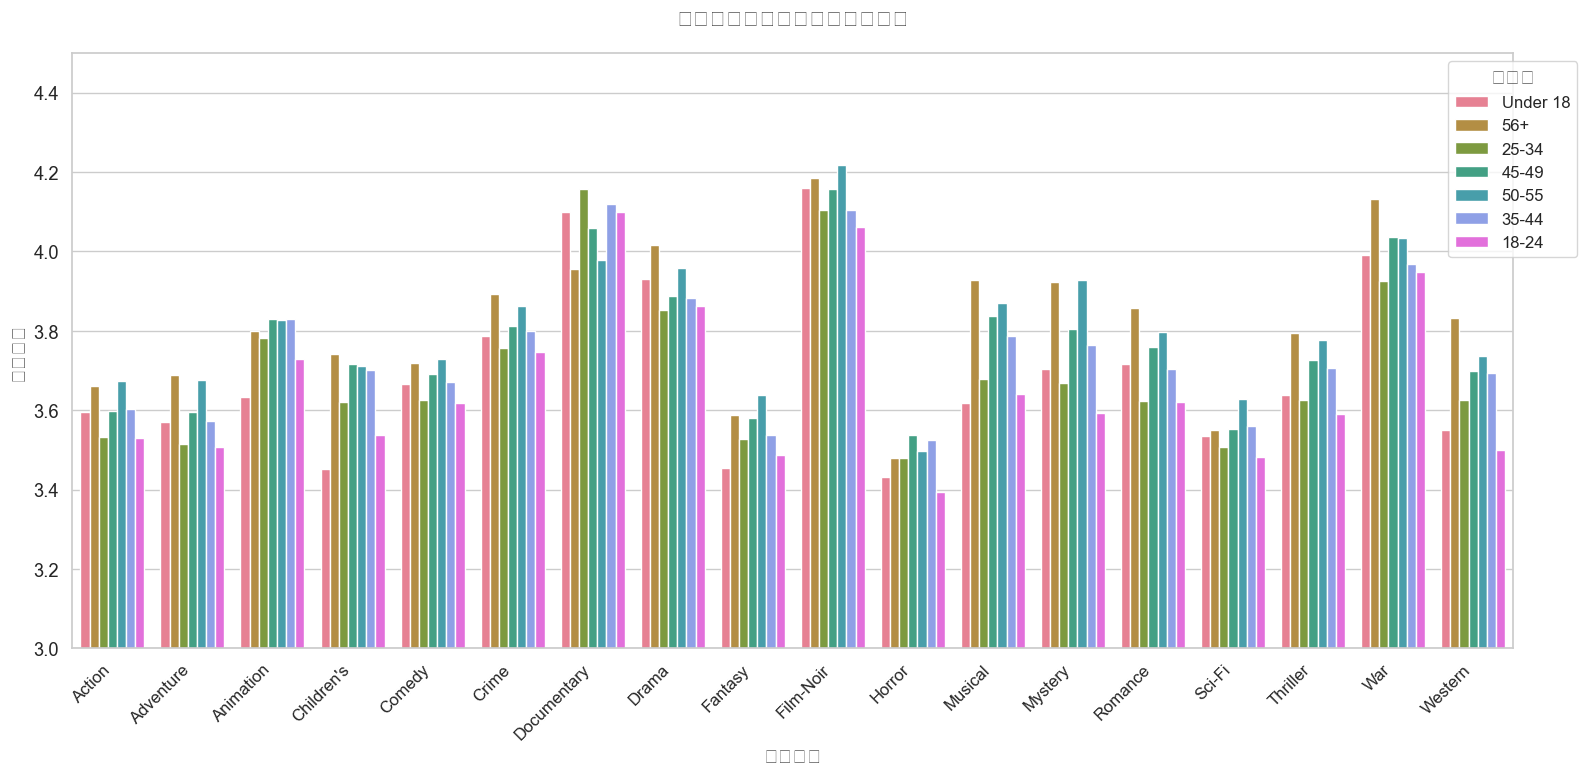

In [76]:
#设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
#设置主题
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.2)

#检查数据格式
print("数据前5行：\n", genre_stats_df.head())
print("\n数据类型：\n", genre_stats_df.dtypes)

plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=genre_stats_df,
    x='genre',
    y='mean_rating',
    hue='age_group',
    errorbar=None,
    order=sorted(genre_stats_df['genre'].unique()),
    dodge=True
)
plt.ylim(3.0, 4.5)
plt.title('各年龄组电影类型平均评分对比', fontsize=16, pad=20)
plt.xlabel('电影类型', fontsize=14)
plt.ylabel('平均评分', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(3.0, 4.6, 0.2))
plt.legend(title='年龄组', bbox_to_anchor=(1.05, 1), fontsize=12)
plt.tight_layout()
plt.show()


可视化2：各年龄组观影数量堆叠图

<Figure size 1400x800 with 0 Axes>

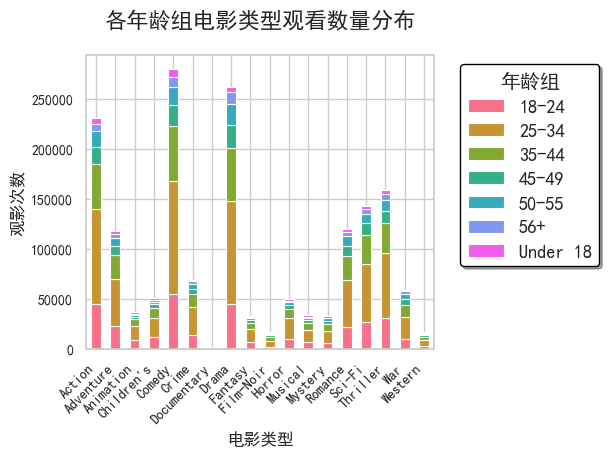

In [77]:
#设置全局样式
sns.set_theme(
    style="whitegrid",
    palette="husl",
    font_scale=1.2
)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#数据透视处理
pivot_count = genre_stats_df.pivot_table(
    index='genre',
    columns='age_group',
    values='watch_count',
    aggfunc='sum'
).fillna(0)

#绘制堆叠柱状图
plt.figure(figsize=(14, 8))
ax = pivot_count.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette("husl", n_colors=pivot_count.shape[1]),  #使用seaborn调色板
    edgecolor='w',  #添加白色边框
    linewidth=0.8
)

#图表装饰
plt.title('各年龄组电影类型观看数量分布', fontsize=16, pad=20)
plt.xlabel('电影类型', fontsize=12)
plt.ylabel('观影次数', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

#优化图例
legend = ax.legend(
    title='年龄组',
    bbox_to_anchor=(1.05, 1),
    frameon=True,
    shadow=True,
    edgecolor='black'
)
legend.get_frame().set_facecolor('white')

plt.tight_layout()
plt.show()

可视化3：主要类型偏好比例雷达图

In [78]:
#数据准备
top_genres = genre_stats_df.groupby('genre')['watch_count'].sum().nlargest(5).index.tolist()
radar_data = genre_stats_df[genre_stats_df['genre'].isin(top_genres)]
    
#生成雷达图
fig = px.line_polar(
    radar_data, 
    r='watch_percent', 
    theta='genre',
    line_close=True,
    color='age_group',
    color_discrete_sequence=sns.color_palette("husl").as_hex(),
    title='主要电影类型年龄偏好比例雷达图',
    template='plotly_white',
    width=800,
    height=500
)

fig.update_layout(
    font=dict(size=12),
    polar=dict(
        radialaxis=dict(visible=True, tickformat=".1%"),
        angularaxis=dict(direction="clockwise")
    )
)
fig.show()

关键分析结果

In [79]:
analysis_report = []

#1.找出每个年龄组最偏好的类型
age_groups = genre_stats_df['age_group'].unique()
for age_group in sorted(age_groups):
    group_data = genre_stats_df[genre_stats_df['age_group'] == age_group]
    # #数据校验
    # if group_data.empty:
    #     analysis_report.append(f"{age_group} 组无有效数据")
    #     continue
    try:
        top_genre = group_data.loc[group_data['watch_percent'].idxmax()]
        analysis_report.append(
            f"{age_group} 组最偏好类型：{top_genre['genre']} "
            f"(占比 {top_genre['watch_percent']:.1f}%)"
        )
    except ValueError:
        analysis_report.append(f"{age_group} 组数据异常")

#2.找出评分差异最大的类型
try:
    rating_std = genre_stats_df.groupby('genre')['mean_rating'].std()
    if not rating_std.empty:
        max_diff = rating_std.idxmax()
        analysis_report.append(f"\n评分差异最大类型：{max_diff} (标准差：{rating_std[max_diff]:.2f})")
    else:
        analysis_report.append("\n评分数据不足")
except Exception as e:
    analysis_report.append(f"\n评分分析失败：{str(e)}")

print("结果分析\n")
print("\n".join(analysis_report))

结果分析

18-24 组最偏好类型：Comedy (占比 16.9%)
25-34 组最偏好类型：Comedy (占比 16.6%)
35-44 组最偏好类型：Comedy (占比 16.1%)
45-49 组最偏好类型：Drama (占比 16.7%)
50-55 组最偏好类型：Drama (占比 17.5%)
56+ 组最偏好类型：Drama (占比 19.4%)
Under 18 组最偏好类型：Comedy (占比 17.7%)

评分差异最大类型：Mystery (标准差：0.13)


## 二、用户对电影的打分预测

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import datetime
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
import re
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



### 示例：基于SVD对用户电影评分数据进行协同过滤预测

这里SVD分解时间较长，略去

In [81]:
# train, test = train_test_split(ratings, test_size=0.2, random_state=42)
# rating_matrix = ratings.pivot(index='user_id', columns='movie_id', values='rating',)
# rating_matrix = rating_matrix.fillna(0)
# train_matrix = rating_matrix.copy()
# for i in range(len(test)):
#     train_matrix.loc[test.iloc[i]['user_id'], test.iloc[i]['movie_id']] = 0
 
# # SVD分解
# svd_k = 100
# svd = TruncatedSVD(n_components=svd_k)
# user_vectors = svd.fit_transform(train_matrix)
# item_vectors = svd.components_.T

# # 预测评分
# predicted_ratings = np.dot(user_vectors, item_vectors.T)
# predicted_ratings = pd.DataFrame(predicted_ratings, index=rating_matrix.index, columns=rating_matrix.columns)

# mse_score = 0
# for i in range(len(test)):
#     mse_score += (max(int(predicted_ratings.loc[test.iloc[i]['user_id'], test.iloc[i]['movie_id']]),0) - test.iloc[i]['rating']) ** 2
# print('MSE:', mse_score / test.shape[0])

### 请你不要局限于对评分矩阵做SVD分解，尝试加入用户类型及偏好进行优化。另：加入电影信息获得好的效果可以加5分。

In [82]:
#基于混合特征的评分预测系统实现

#数据加载与预处理
ratings = pd.read_csv('./ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'],
        dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')
users = pd.read_csv( './users.csv', usecols=['user_id', 'gender', 'age_desc', 'occ_desc'],
        dtype={'user_id': 'int32', 'gender': 'category'}, encoding='latin-1')
movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
        dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv( './info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
        dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'},encoding='latin-1'
    ).rename(columns={'id': 'movie_id', 'starts': 'stars'})

#内存优化：通过指定dtype参数减少内存占用
#category类型适用于有限取值的字符串字段（如gender）
#特征融合：将导演、编剧、主演合并为creative_team字段
#|符分隔保留原始信息便于后续文本特征提取

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(int)
    except:
        return 2000
def process_age(age_desc):
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40, '45-49': 47, '50-55': 52, '56+': 60}
    return age_desc.map(age_map)

users['age'] = process_age(users['age_desc'])
movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['stars']

#合并评分数据和真实用户数据
data = pd.merge(ratings, users, on='user_id')
#继续合并电影数据
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'stars']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')

In [83]:
#特征工程处理流程

#用户特征处理逻辑：

#原始特征 → OneHot编码 → PCA降维 → 低维稠密向量
#PCA n_components=0.95 自适应降维至保留95%原始信息
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

#电影特征处理逻辑：

#genres处理：
#直接进行OneHot编码，生成类型特征矩阵

#creative_team处理：
#TF-IDF参数：tokenizer=lambda x: x.split('|')：按管道符分割人名；max_features=500：保留最高频500个人物
#TruncatedSVD压缩至50维

#intro处理：
#ngram_range=(1,2)捕获单词和短语
#100维保留关键语义信息
movie_transformer = ColumnTransformer(
    [   ('genres', OneHotEncoder(), ['genres']),

        (   'creative_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(tokenizer=lambda x: x.split('|'),max_features=500,min_df=5)),
                    ('svd', TruncatedSVD(n_components=50, random_state=42))   ]
            ),
            'creative_team'   ),

        (   'intro_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ), 
            'intro'   ),
        
        ('year', 'passthrough', ['release_year'])   ]
)

#全局特征处理器

#输入数据 → 列分流处理（分为用户特征(OneHot+PCA)+电影特征(多模态处理)） → 特征拼接 → 最终特征矩阵
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'age', 'occ_desc']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')

In [84]:
#划分数据集
X = data[['gender', 'age', 'occ_desc', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
#20%测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('preprocessor', preprocessor), #特征工程
    ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, #LightGBM回归
        subsample=0.8, random_state=42, verbose=-1))
])
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5)  #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')
#MSE（0.9680）
#Accuracy（0.3757）
#四舍五入后计算分类准确率
#37.57%的准确率在5分类任务中属于合理水平

MSE: 0.9680
Accuracy: 0.3757


In [85]:

# 评分参考
def grade(score):
    if score >= 2:
        return 0
    elif score >= 1:
        return 30
    else:
        return 40
print("Score:",grade(mse))

Score: 40


## 三、电影海报聚类分析

In [86]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
from img2vec_pytorch import Img2Vec


#文件夹路径
folder_path = "./poster"

#初始化特征列表
features = []

img2vec_model = Img2Vec()
#遍历文件夹中的每个海报图像
for filename in os.listdir(folder_path):
    if filename.endswith(".jpg") or filename.endswith(".png"):
        #读取图像
        image_path = os.path.join(folder_path, filename)
        image = cv2.imread(image_path)

        #提取颜色直方图和灰度直方图特征
        image = Image.open(image_path)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        vector = img2vec_model.get_vec(image)

        feature_vector = vector

        #添加图像文件前缀（电影ID）和特征向量到特征列表中
        features.append([filename.split('.')[0], feature_vector])

#将特征列表转换为DataFrame
columns = ['movie_id', 'features']
df = pd.DataFrame(features, columns=columns)

print("带有电影ID和特征向量的DataFrame:")
print(df.head())

带有电影ID和特征向量的DataFrame:
  movie_id                                           features
0        1  [1.2273525, 1.1728468, 0.29160962, 3.7952738, ...
1       10  [0.6591355, 0.563311, 0.1754671, 0.47256583, 0...
2      100  [1.270225, 2.129366, 0.1338063, 0.0, 0.0327485...
3     1003  [1.4408051, 1.2796657, 0.79114556, 0.65906763,...
4     1004  [0.54259104, 0.7196604, 0.11201007, 0.7017186,...


### 无监督聚类结果的可视化

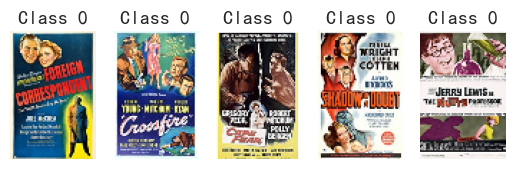

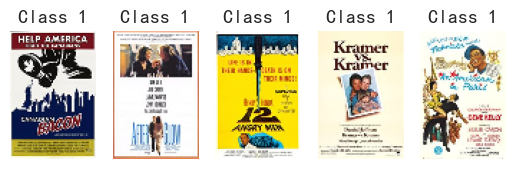

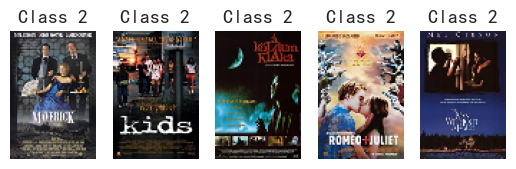

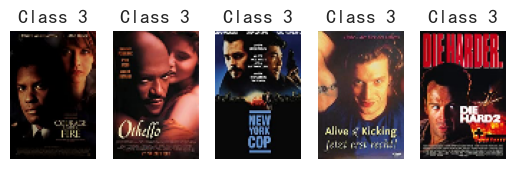

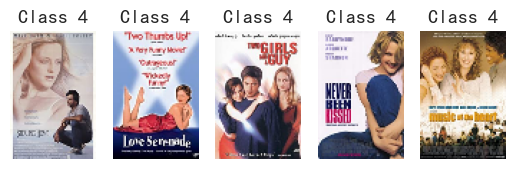

In [87]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#将特征向量转换为numpy数组
feature_matrix = np.vstack(df['features'].values)

#执行K-means聚类（假设分为5类）
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(feature_matrix)

#获取每个类别的代表性图像（每个类别取5个）
representative_images = []
for i in range(n_clusters):
    #获取当前类别的所有样本索引
    class_indices = np.where(cluster_labels == i)[0]
    
    #计算样本到聚类中心的距离
    distances = np.linalg.norm(feature_matrix[class_indices] - kmeans.cluster_centers_[i], axis=1)
    
    #选择距离最近的5个样本作为代表
    representative_indices = class_indices[np.argsort(distances)[:5]]
    representative_images.append(representative_indices)

#打印每个类别的代表性图像
for i, indices in enumerate(representative_images):
    #设置图像的大小
    for j, index in enumerate(indices):
        #读取代表性图像
        representative_image_path = os.path.join(folder_path, os.listdir(folder_path)[index])
        representative_image = cv2.imread(representative_image_path)
        representative_image = cv2.resize(representative_image, (60, 90))
        #绘制图像
        plt.subplot(1, 5, j+1)
        plt.imshow(cv2.cvtColor(representative_image, cv2.COLOR_BGR2RGB))
        plt.title("Class {}".format(i))
        plt.axis("off")

    plt.show()


### 有监督聚类

In [88]:
import pandas as pd

#读取CSV文件
movies_df = pd.read_csv("./movies.csv")

#提取genre信息
genres = movies_df['genres']
#初始化genre的字典
genre_dict = {}

#遍历每个电影的genre信息
for genre_string in genres:
    #将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    #遍历列表中的每个genre
    for genre in genre_list:
        #将genre添加到字典中，如果已存在则不重复添加
        if genre not in genre_dict:
            genre_dict[genre] = len(genre_dict)

#输出genre字典
print("Genre Dictionary:")
print(genre_dict)

Genre Dictionary:
{'Animation': 0, "Children's": 1, 'Comedy': 2, 'Adventure': 3, 'Fantasy': 4, 'Romance': 5, 'Drama': 6, 'Action': 7, 'Crime': 8, 'Thriller': 9, 'Horror': 10, 'Sci-Fi': 11, 'Documentary': 12, 'War': 13, 'Musical': 14, 'Mystery': 15, 'Film-Noir': 16, 'Western': 17}


In [89]:

#将genre信息转换为向量形式
genre_vectors = []

#遍历每个电影的genre信息
for genre_string in genres:
    #将genre字符串按照"|"分割成列表
    genre_list = genre_string.split("|")
    #初始化genre向量
    genre_vector = [0] * len(genre_dict)
    #根据genre列表设置向量中对应的位置为1
    for genre in genre_list:
        genre_vector[genre_dict[genre]] = 1
    #将genre向量添加到列表中
    genre_vectors.append(genre_vector)

#将genre向量转换为列表
genre_lists = [list(genre_vector) for genre_vector in genre_vectors]

#将genre列表添加到movies_df中
movies_df['genre_vector'] = genre_lists

#输出带有genre向量的movies_df
print("Movies DataFrame with Genre Vector:")
print(movies_df.head())

Movies DataFrame with Genre Vector:
   Unnamed: 0  movie_id                               title  \
0           0         1                    Toy Story (1995)   
1           1         2                      Jumanji (1995)   
2           2         3             Grumpier Old Men (1995)   
3           3         4            Waiting to Exhale (1995)   
4           4         5  Father of the Bride Part II (1995)   

                         genres  \
0   Animation|Children's|Comedy   
1  Adventure|Children's|Fantasy   
2                Comedy|Romance   
3                  Comedy|Drama   
4                        Comedy   

                                        genre_vector  
0  [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
1  [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2  [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
3  [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  


In [90]:
#将电影ID列转换为整数类型
movies_df['movie_id'] = movies_df['movie_id'].astype(int)
df['movie_id'] = df['movie_id'].astype(int)

In [91]:
#使用merge方法按照movie_id合并两个DataFrame
merged_df = pd.merge(movies_df, df, on='movie_id', how='inner')

#输出合并后的DataFrame
print("Merged DataFrame:")
print(merged_df.head())

Merged DataFrame:
   Unnamed: 0  movie_id                               title  \
0           0         1                    Toy Story (1995)   
1           1         2                      Jumanji (1995)   
2           2         3             Grumpier Old Men (1995)   
3           3         4            Waiting to Exhale (1995)   
4           4         5  Father of the Bride Part II (1995)   

                         genres  \
0   Animation|Children's|Comedy   
1  Adventure|Children's|Fantasy   
2                Comedy|Romance   
3                  Comedy|Drama   
4                        Comedy   

                                        genre_vector  \
0  [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                            features  


In [92]:
print(merged_df.columns)

Index(['Unnamed: 0', 'movie_id', 'title', 'genres', 'genre_vector',
       'features'],
      dtype='object')


In [93]:
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#提取特征和标签
X = np.array(merged_df['features'].tolist())
y = np.array(merged_df['genre_vector'].tolist())


#特征预处理
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#PCA降维（保留95%方差）
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

#划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)


In [94]:

# # 创建多标签 k 近邻分类器
# knn = KNeighborsClassifier()
# multi_knn = MultiOutputClassifier(knn, n_jobs=-1)

# # 训练分类器
# multi_knn.fit(X_train, y_train)

# # 预测
# y_pred = multi_knn.predict(X_test)

# # 评估分类器性能
# accuracy = accuracy_score(y_test, y_pred)

# 参数网格（优化后的参数）
param_grid = {
    'estimator__n_estimators': [200, 300],
    'estimator__max_depth': [15, 20],
    'estimator__min_samples_split': [5, 10],
    'estimator__class_weight': ['balanced']
}

#创建优化后的随机森林分类器
rf = RandomForestClassifier(random_state=42)
multi_rf = MultiOutputClassifier(rf, n_jobs=-1)

#网格搜索
grid_search = GridSearchCV(multi_rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

#最佳模型
best_model = grid_search.best_estimator_

#预测与评估
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.03231292517006803
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.00      0.00      0.00        51
           2       0.69      0.06      0.11       181
           3       0.00      0.00      0.00        49
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00        77
           6       0.70      0.11      0.19       251
           7       0.00      0.00      0.00        96
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00        73
          10       0.00      0.00      0.00        57
          11       0.00      0.00      0.00        44
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00        26
          14       0.00      0.00      0.00        22
          15       0.00      0.00      0.00        18
          16       0.00     

In [95]:
# 评分参考
accuracy_score = 0
def grade(score):
    if score <= 0.2:
        return 0
    elif score <= 0.3:
        return 30
    elif score <= 0.4:
        return 40
    else:
        return 50

### 性别预测

In [96]:
#读取数据并筛选热门电影

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

#读取数据
ratings = pd.read_csv('ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv('movies.csv')
users = pd.read_csv('users.csv')[['user_id', 'gender']]

#筛选热门电影（评分次数 > 300）
popular_movies = ratings['movie_id'].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings['movie_id'].isin(popular_movies)]

#合并评分与电影类型数据
ratings_movies = pd.merge(ratings_filtered, movies, on='movie_id')

#拆分电影类型为多行
ratings_movies['genres'] = ratings_movies['genres'].str.split('|')
ratings_exploded = ratings_movies.explode('genres')

#计算用户对每个类型的平均评分
user_genre_avg = ratings_exploded.groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)

In [97]:
#合并用户性别
data = pd.merge(users, user_genre_avg, on='user_id')

#将性别转换为数值（F=0, M=1）
data['gender'] = data['gender'].map({'F': 0, 'M': 1})

In [98]:
#分割特征和标签
X = data.drop(['user_id', 'gender'], axis=1)
y = data['gender']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [99]:
#模型训练
#构建包含过采样-标准化-特征选择-分类器的完整管道
#SMOTE解决类别不平衡问题（F/M样本比1:1.8）
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=10)),
    ('classifier', LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [100]:
#训练模型
pipeline.fit(X_train, y_train)

#预测与评估
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


print("分类报告")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

分类报告
              precision    recall  f1-score   support

           0       0.43      0.58      0.49       358
           1       0.79      0.67      0.73       850

    accuracy                           0.64      1208
   macro avg       0.61      0.63      0.61      1208
weighted avg       0.68      0.64      0.66      1208

ROC-AUC: 0.6745054222806441


In [101]:
X_all = data.drop(['user_id', 'gender'], axis=1)
all_gender_pred = pipeline.predict(X_all)

#转换为'F'/'M'并合并到用户数据
data['gender_pred'] = all_gender_pred
data['gender_pred'] = data['gender_pred'].map({0: 'F', 1: 'M'})

#合并到原始用户表
users = pd.merge(users[['user_id', 'gender']], data[['user_id', 'gender_pred']], on='user_id', how='left')
users['gender_pred'] = users['gender_pred'].fillna(users['gender'])

#保存到CSV
users.to_csv("users_with_predictions.csv", index=False)

### 年龄预测

In [102]:
%pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [103]:
import pandas as pd
import numpy as np
import mord
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, classification_report
from skopt import BayesSearchCV

#读取数据
ratings = pd.read_csv('ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'])
movies = pd.read_csv('movies.csv')
users = pd.read_csv('users.csv')[['user_id', 'gender', 'occupation', 'age_desc']]

#定义年龄段顺序
age_order = ['Under 18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
users['age_ordinal'] = users['age_desc'].map({k: v for v, k in enumerate(age_order)})

#筛选热门电影（评分次数>300）
popular_movies = ratings['movie_id'].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings['movie_id'].isin(popular_movies)]

#合并数据并计算用户对电影类型的平均评分
merged_data = pd.merge(ratings_filtered, movies, on='movie_id')
merged_data = pd.merge(merged_data, users, on='user_id')

#拆分电影类型并展开
merged_data['genres'] = merged_data['genres'].str.split('|')
exploded_data = merged_data.explode('genres')
user_genre_avg = exploded_data.groupby(['user_id', 'genres'])['rating'].mean().unstack(fill_value=0)

#合并用户特征（性别、职业）
user_features = users.set_index('user_id')[['gender', 'occupation', 'age_ordinal']]
user_genre_avg_reset = user_genre_avg.reset_index()
data = pd.merge(user_genre_avg_reset, user_features.reset_index(), on='user_id', how='inner')

#分割数据集
X = data.drop('age_ordinal', axis=1)
y = data['age_ordinal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
#定义特征处理管道（编码分类变量）
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), user_genre_avg.columns.tolist()),
        ('cat', OneHotEncoder(), ['gender', 'occupation'])
    ])

#使用序数回归模型
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', mord.OrdinalRidge())
])

#训练模型
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Action', 'Adventure',
                                                   'Animation', "Children's",
                                                   'Comedy', 'Crime',
                                                   'Documentary', 'Drama',
                                                   'Fantasy', 'Film-Noir',
                                                   'Horror', 'Musical',
                                                   'Mystery', 'Romance',
                                                   'Sci-Fi', 'Thriller', 'War',
                                                   'Western']),
                                                 ('cat', OneHotEncoder(),
                                                  ['gender', 'occupation'])])),
                ('regressor', OrdinalRidge())])

In [105]:
#预测测试集
y_pred = model.predict(X_test).astype(int)

#计算分类报告和MAE
age_midpoints = {
    'Under 18': 9, '18-24': 21, '25-34': 29.5,
    '35-44': 39.5, '45-49': 47, '50-55': 52.5, '56+': 60
}
y_test_labels = [age_order[i] for i in y_test]
y_pred_labels = [age_order[i] for i in y_pred]

print("=== 分类报告 ===")
print(classification_report(y_test_labels, y_pred_labels, labels=age_order))

y_test_mae = [age_midpoints[label] for label in y_test_labels]
y_pred_mae = [age_midpoints[label] for label in y_pred_labels]
print(f"\nMAE (年龄中位数误差)\n{mean_absolute_error(y_test_mae, y_pred_mae):.1f} 岁")

=== 分类报告 ===
              precision    recall  f1-score   support

    Under 18       0.78      0.70      0.74        57
       18-24       0.73      0.35      0.47       239
       25-34       0.42      0.23      0.30       410
       35-44       0.24      0.74      0.36       231
       45-49       0.15      0.10      0.12       100
       50-55       0.31      0.06      0.10        87
         56+       0.93      0.15      0.27        84

    accuracy                           0.35      1208
   macro avg       0.51      0.33      0.34      1208
weighted avg       0.47      0.35      0.33      1208


MAE (年龄中位数误差)
8.0 岁


In [106]:
#对比逻辑回归（忽略顺序）
from sklearn.linear_model import LogisticRegression

#逻辑回归管道
logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial', max_iter=1000))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

#评测
print("\n=== Logistic Regression (Baseline) ===")
print(classification_report(y_test_labels, [age_order[i] for i in y_pred_logreg], labels=age_order))
y_pred_logreg_mae = [age_midpoints[age_order[i]] for i in y_pred_logreg]
mae_logreg = mean_absolute_error(y_test_mae, y_pred_logreg_mae)
print(f"MAE (Logistic Regression): {mae_logreg:.2f} years")


=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

    Under 18       0.79      0.77      0.78        57
       18-24       0.68      0.44      0.53       239
       25-34       0.41      0.83      0.55       410
       35-44       0.31      0.11      0.17       231
       45-49       0.25      0.03      0.05       100
       50-55       0.08      0.02      0.04        87
         56+       0.69      0.32      0.44        84

    accuracy                           0.45      1208
   macro avg       0.46      0.36      0.36      1208
weighted avg       0.44      0.45      0.40      1208

MAE (Logistic Regression): 7.62 years


In [107]:
X_all = data.drop('age_ordinal', axis=1)
all_age_pred_ordinal = model.predict(X_all).astype(int)
all_age_pred_labels = [age_order[i] for i in all_age_pred_ordinal]

#合并到用户数据
data['age_pred'] = all_age_pred_labels
users_with_predictions = pd.merge(users[['user_id', 'age_desc']], data[['user_id', 'age_pred']], on='user_id',how='left')
users_with_predictions['age_pred'] = users_with_predictions['age_pred'].fillna(users_with_predictions['age_desc'])

#合并到users_with_predictions.csv
try:
    existing_users = pd.read_csv("users_with_predictions.csv")
    users_merged = pd.merge(existing_users, users_with_predictions[['user_id', 'age_pred']], on='user_id', how='left')
except FileNotFoundError:
    users_merged = users_with_predictions

users_merged.to_csv("users_with_predictions.csv", index=False)

### 职业预测

In [108]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

#读取数据
ratings = pd.read_csv("ratings2.csv", header=None,names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("movies.csv")
users = pd.read_csv("users.csv")[["user_id", "gender", "age", "occ_desc"]]

#筛选热门电影（评分次数>300）
popular_movies = ratings["movie_id"].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings["movie_id"].isin(popular_movies)]

#合并数据并计算用户对电影类型的平均评分
merged_data = pd.merge(ratings_filtered, movies, on="movie_id")
merged_data = pd.merge(merged_data, users, on="user_id")

#拆分电影类型并展开
merged_data["genres"] = merged_data["genres"].str.split("|")
exploded_data = merged_data.explode("genres")
user_genre_avg = exploded_data.groupby(["user_id", "genres"])["rating"].mean().unstack(fill_value=0)
user_genre_avg_reset = user_genre_avg.reset_index()

#合并用户特征（性别、年龄）
user_features = users[["user_id", "gender", "age", "occ_desc"]]
data = pd.merge(user_genre_avg, user_features, on="user_id", how="inner")

#检查职业类别分布
print("职业类别分布:\n", data["occ_desc"].value_counts())

#分割数据集
X = data.drop("occ_desc", axis=1)
y = data["occ_desc"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#定义特征处理（标准化数值特征+编码分类变量）
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), user_genre_avg.columns.tolist()), #电影类型评分
        ("cat", OneHotEncoder(), ["gender"]), #性别OneHot编码
        ("age", StandardScaler(), ["age"]) #年龄标准化
    ]
)

#使用imblearn的Pipeline整合预处理和SMOTE
pipeline = make_pipeline(preprocessor, SMOTE(random_state=42),
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))

#训练模型
pipeline.fit(X_train, y_train)

#预测测试集
y_pred = pipeline.predict(X_test)

#输出分类报告
print("\n分类报告")
print(classification_report(y_test, y_pred, zero_division=0))

职业类别分布:
 occ_desc
college/grad student      759
other or not specified    711
executive/managerial      679
academic/educator         528
technician/engineer       502
programmer                388
sales/marketing           302
writer                    281
artist                    267
self-employed             241
doctor/health care        236
K-12 student              195
clerical/admin            173
scientist                 144
retired                   142
lawyer                    129
customer service          112
homemaker                  92
unemployed                 72
tradesman/craftsman        70
farmer                     17
Name: count, dtype: int64

分类报告
                        precision    recall  f1-score   support

          K-12 student       0.69      0.74      0.72        39
     academic/educator       0.08      0.06      0.07       106
                artist       0.08      0.06      0.07        54
        clerical/admin       0.07      0.09      0.08        35

In [110]:
#预测所有用户的职业
X_all = data.drop("occ_desc", axis=1)
all_occ_pred = pipeline.predict(X_all)

#合并到用户数据
data['occ_pred'] = all_occ_pred
users_with_predictions = pd.merge(users[['user_id', 'occ_desc']], data[['user_id', 'occ_pred']], on='user_id', how='left')
users_with_predictions['occ_pred'] = users_with_predictions['occ_pred'].fillna(users_with_predictions['occ_desc'])

#合并到users_with_predictions.csv
try:
    existing_users = pd.read_csv("users_with_predictions.csv")
    users_merged = pd.merge(existing_users, users_with_predictions[['user_id', 'occ_pred']], on='user_id', how='left')
except FileNotFoundError:
    users_merged = users_with_predictions

users_merged.to_csv("users_with_predictions.csv", index=False)

### 用户画像可视化

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#读取数据
users = pd.read_csv("users_with_predictions.csv")  # 包含gender_pred, age_pred, occ_pred
ratings = pd.read_csv("ratings2.csv", names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("movies.csv")

#筛选热门电影（评分次数>300）
popular_movies = ratings["movie_id"].value_counts()[lambda x: x > 300].index
ratings_filtered = ratings[ratings["movie_id"].isin(popular_movies)]

#合并所有数据
data = pd.merge(pd.merge(ratings_filtered, users, on="user_id"), movies, on="movie_id")

#拆分电影类型为独立列（0/1）
genres_list = movies["genres"].str.split("|").explode().unique()
for genre in genres_list:
    data[genre] = data["genres"].str.contains(genre).astype(int)

<Figure size 1200x800 with 0 Axes>

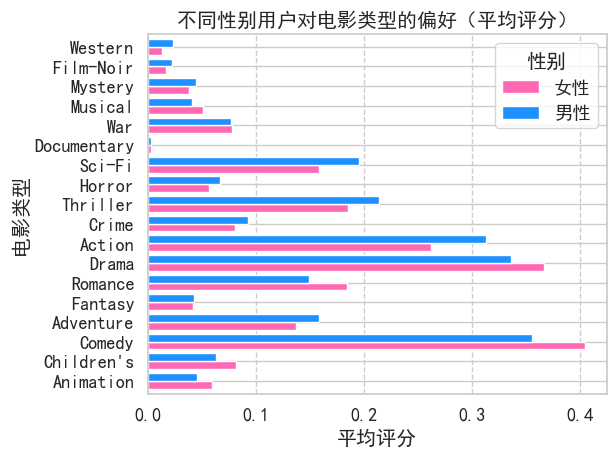

In [112]:
#按预测性别分组计算类型平均分
gender_preference = data.groupby("gender_pred")[genres_list].mean().T

#绘制横向条形图
plt.figure(figsize=(12, 8))
gender_preference.plot.barh(width=0.8, color=["#FF69B4", "#1E90FF"])
plt.title("不同性别用户对电影类型的偏好（平均评分）")
plt.xlabel("平均评分")
plt.ylabel("电影类型")
plt.legend(title="性别", labels=["女性", "男性"])
plt.grid(axis="x", linestyle="--")
plt.tight_layout()
plt.savefig("gender_genre_preference.png")
plt.show()

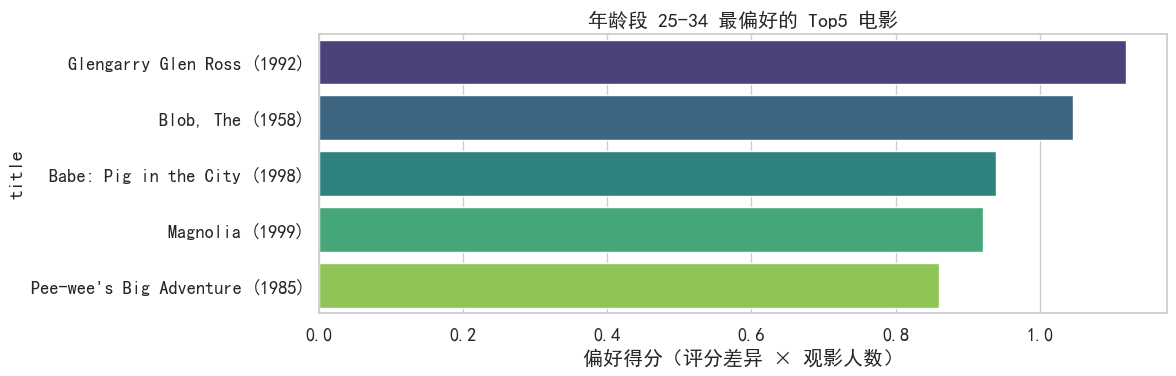

In [113]:
def plot_age_top_movies(age_group):
    #读取包含预测结果的用户数据
    users_with_pred = pd.read_csv("users_with_predictions.csv")
    
    #合并数据
    data = pd.merge(ratings_filtered[["user_id", "movie_id", "rating"]],
        users_with_pred[["user_id", "age_pred"]], on="user_id", how="left")
    data = pd.merge(data, movies[["movie_id", "title", "genres"]], on="movie_id")
    
    #过滤指定年龄段
    age_data = data[data["age_pred"] == age_group]
    
    #计算电影评分指标：评分差异加权
    mean_rating = data.groupby("movie_id")["rating"].mean()
    age_rating = age_data.groupby("movie_id")["rating"].mean()
    score = (age_rating - mean_rating) * np.log(age_data["movie_id"].value_counts() + 1) #避免log(0)
    
    #获取Top5电影
    top_movies = score.nlargest(5).index
    top_details = movies[movies["movie_id"].isin(top_movies)][["title", "genres"]]
    
    plt.figure(figsize=(12, 4))
    sns.barplot(x=score[top_movies].values, y=top_details["title"], palette="viridis")
    plt.title(f"年龄段 {age_group} 最偏好的 Top5 电影")
    plt.xlabel("偏好得分（评分差异 × 观影人数）")
    plt.tight_layout()
    plt.savefig(f"age_{age_group}_top_movies.png")
    plt.show()

#示例：可视化25-34岁用户偏好
plot_age_top_movies("25-34")

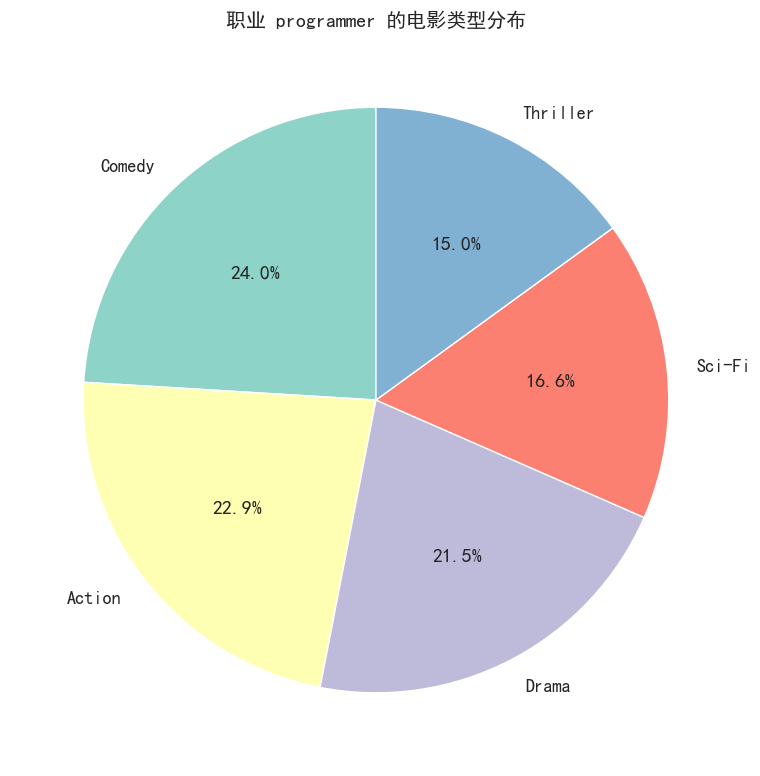

In [114]:
def plot_occupation_genre_distribution(occupation):
    #过滤职业群体并统计类型出现频次
    occ_data = data[data["occ_pred"] == occupation]
    genre_counts = occ_data[genres_list].sum().sort_values(ascending=False).head(5)
    
    #绘制饼图
    plt.figure(figsize=(8, 8))
    genre_counts.plot.pie(autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set3"))
    plt.title(f"职业 {occupation} 的电影类型分布")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(f"occupation_{occupation}_genre_distribution.png")
    plt.show()

#示例：分析程序员群体
plot_occupation_genre_distribution("programmer")

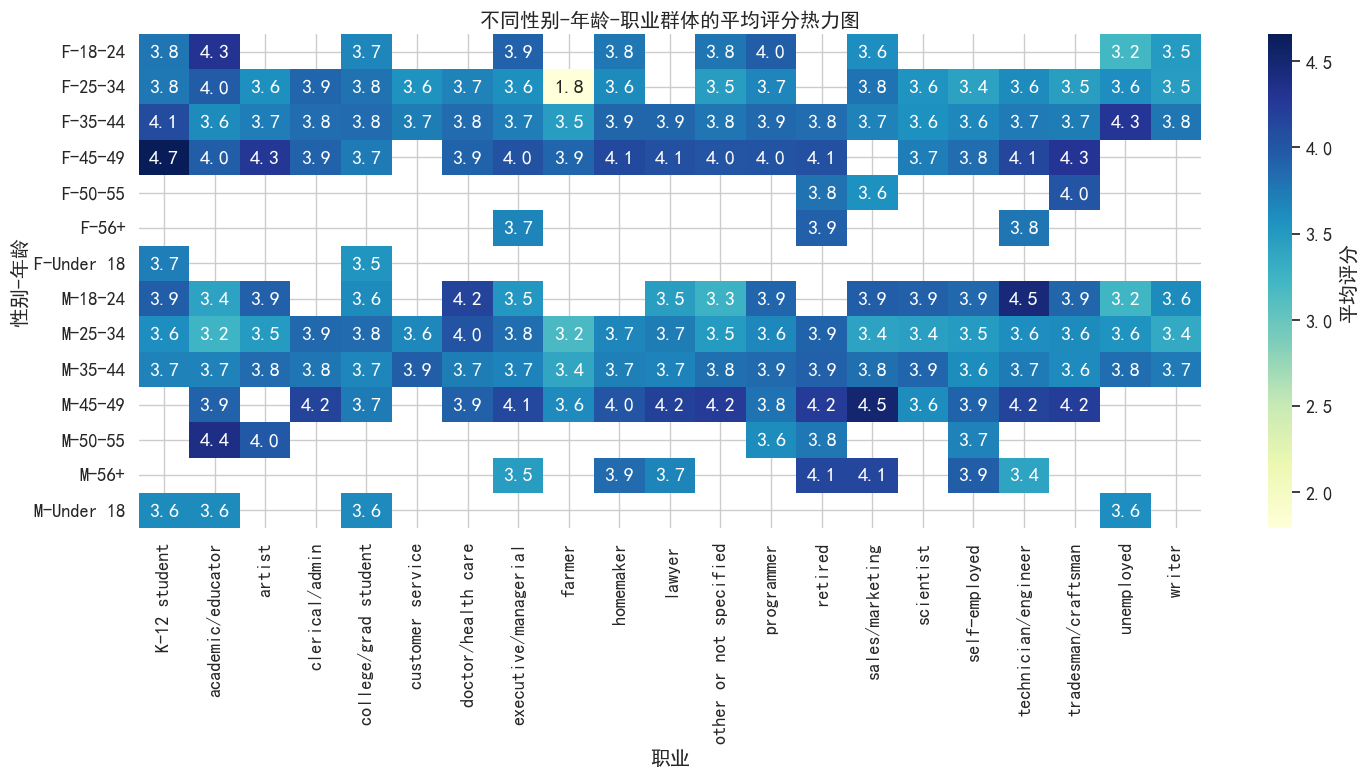

In [115]:

#计算各群体的平均评分
heatmap_data = data.groupby(["gender_pred", "age_pred", "occ_pred"])["rating"].mean().reset_index()
    
#生成透视表
pivot_table = heatmap_data.pivot_table(
    index=["gender_pred", "age_pred"],
    columns="occ_pred",
    values="rating",
    aggfunc="mean"
)
    
#可视化热力图
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={"label": "平均评分"})
plt.title("不同性别-年龄-职业群体的平均评分热力图")
plt.xlabel("职业")
plt.ylabel("性别-年龄")
plt.tight_layout()
plt.savefig("gender_age_occupation_heatmap.png")
plt.show()

### 仅加入性别预测优化用户评分

In [116]:
ratings = pd.read_csv('./ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')
#仅使用性别预测结果
users_pred = pd.read_csv('users_with_predictions.csv', usecols=['user_id', 'gender_pred'],
    dtype={'user_id': 'int32', 'gender_pred': 'category'}, encoding='latin-1')
#读取原始用户表（仅保留user_id用于关联）
users_raw = pd.read_csv('./users.csv', usecols=['user_id'], dtype={'user_id': 'int32'}, encoding='latin-1')
movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
    dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv('./info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
    dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'}, encoding='latin-1'
    ).rename(columns={'id': 'movie_id', 'starts': 'stars'})

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(int)
    except:
        return 2000

users = pd.merge(users_raw, users_pred, on='user_id', how='left')
users = users.rename(columns={'gender_pred': 'gender'})

movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['stars']

#合并数据集
data = pd.merge(ratings, users[['user_id', 'gender']], on='user_id')
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'stars']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')

#用户特征处理（类别型）
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

#电影特征处理
movie_transformer = ColumnTransformer([
    ('genres', OneHotEncoder(), ['genres']),
    ('creative_tfidf', Pipeline([
        ('tfidf', TfidfVectorizer(
            tokenizer=lambda x: x.split('|'),
            max_features=500,
            min_df=5
        )),
        ('svd', TruncatedSVD(n_components=50, random_state=42))
    ]), 'creative_team'),
    ('intro_tfidf', Pipeline([
        ('tfidf', TfidfVectorizer(
            stop_words='english',
            max_features=1000,
            ngram_range=(1,2)
        )),
        ('svd', TruncatedSVD(n_components=100, random_state=42))
    ]), 'intro'),
    ('year', 'passthrough', ['release_year'])
])

#全局特征处理器
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')

In [117]:
#划分数据集
X = data[['gender', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(
    [   ('preprocessor', preprocessor),
        ('regressor', LGBMRegressor(n_estimators=150, learning_rate=0.1, max_depth=6,
            subsample=0.6, random_state=42, verbose=-1))   ]
)
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5) #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')

MSE: 0.9869
Accuracy: 0.3718


### 仅加入年龄预测优化用户评分


In [118]:
ratings = pd.read_csv('./ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')

#加载预测年龄
users_pred = pd.read_csv('users_with_predictions.csv', usecols=['user_id', 'age_pred'],
    dtype={'user_id': 'int32', 'age_pred': 'category'}, encoding='latin-1')

users_raw = pd.read_csv('./users.csv', usecols=['user_id'], dtype={'user_id': 'int32'}, encoding='latin-1')

def process_age_pred(age_pred_str): #将预测的年龄段字符串转换为数值
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40,
        '45-49': 47, '50-55': 52, '56+': 60}
    return age_pred_str.map(age_map)

users = pd.merge(users_raw, users_pred, on='user_id', how='left').rename(columns={'age_pred': 'age'})
users['age'] = process_age_pred(users['age'])

movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
    dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv('./info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
    dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'}, encoding='latin-1'
    ).rename(columns={'id': 'movie_id', 'starts': 'stars'})

movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['stars']

#合并数据集
data = pd.merge(ratings, users[['user_id', 'age']], on='user_id') #使用预测年龄
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

#填充缺失值
data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'stars']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')

#用户特征处理
user_transformer = Pipeline([
    ('scaler', StandardScaler()),  # 数值型特征标准化
    ('pca', PCA(n_components=1))   # 单列年龄无需复杂降维
])

#电影特征处理
movie_transformer = ColumnTransformer(
    [   ('genres', OneHotEncoder(), ['genres']),

        (   'creative_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(tokenizer=lambda x: x.split('|'),max_features=500,min_df=5)),
                    ('svd', TruncatedSVD(n_components=50, random_state=42))   ]
            ),
            'creative_team'   ),

        (   'intro_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ), 
            'intro'   ),
        
        ('year', 'passthrough', ['release_year'])   ]
)

#全局特征处理器
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['age']),
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')

In [119]:
#划分数据集
X = data[['age', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline(
    [   ('preprocessor', preprocessor),
        ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
            subsample=0.8, random_state=42, verbose=-1))   ]
)

#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5) #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')

MSE: 0.9713
Accuracy: 0.3746


### 加入职业及性别、年龄预测优化用户评分

In [120]:
ratings = pd.read_csv('./ratings2.csv', header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': 'int32', 'movie_id': 'int32', 'rating': 'float32'}, encoding='latin-1')
users_pred = pd.read_csv('users_with_predictions.csv', 
    usecols=['user_id', 'gender_pred', 'age_pred', 'occ_pred'],
    dtype={'user_id': 'int32', 'gender_pred': 'category', 'age_pred': 'category', 'occ_pred': 'category'},
    encoding='latin-1'
)
users_raw = pd.read_csv('./users.csv', usecols=['user_id'], dtype={'user_id': 'int32'}, encoding='latin-1')

movies = pd.read_csv('./movies.csv', usecols=['movie_id', 'genres'],
    dtype={'movie_id': 'int32', 'genres': 'category'}, encoding='latin-1')
movies_info = pd.read_csv('./info.csv', usecols=['id', 'release_time', 'intro', 'directors', 'writers', 'starts'],
    dtype={'intro': 'string', 'directors': 'string', 'writers': 'string'}, encoding='latin-1'
    ).rename(columns={'id': 'movie_id', 'starts': 'stars'})

def extract_year(time_str):
    try:
        return pd.to_datetime(time_str, errors='coerce').year.fillna(2000).astype(int)
    except:
        return 2000
def process_age(age_desc):
    age_map = {'Under 18': 18, '18-24': 21, '25-34': 30, '35-44': 40, '45-49': 47, '50-55': 52, '56+': 60}
    return age_desc.map(age_map)

users = pd.merge(users_raw, users_pred, on='user_id', how='left').rename(columns={
    'gender_pred': 'gender', 'age_pred': 'age', 'occ_pred': 'occ_desc'})
users['age'] = process_age(users['age'])
movies_info['release_year'] = movies_info['release_time'].apply(extract_year)
movies_info['creative_team'] = movies_info['directors'] + '|' + movies_info['writers'] + '|' + movies_info['stars']

#合并数据集
data = pd.merge(ratings, users[['user_id', 'gender', 'age', 'occ_desc']], on='user_id')
data = pd.merge(data, movies, on='movie_id')
data = pd.merge(data, movies_info, on='movie_id')

data['release_year'] = data['release_year'].fillna(2000)
text_columns = ['creative_team', 'intro', 'directors', 'writers', 'stars']
data[text_columns] = data[text_columns].fillna('Unknown')
data['creative_team'] = data['creative_team'].replace('', 'Unknown')

#用户特征处理（类别型）
user_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ('pca', PCA(n_components=0.95, random_state=42))
])

#电影特征处理
movie_transformer = ColumnTransformer(
    [   ('genres', OneHotEncoder(), ['genres']),

        (   'creative_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(tokenizer=lambda x: x.split('|'),max_features=500,min_df=5)),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ),
            'creative_team'   ),

        (   'intro_tfidf',
            Pipeline(
                [   ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1,2))),
                    ('svd', TruncatedSVD(n_components=100, random_state=42))   ]
            ), 
            'intro'   ),
        
        ('year', 'passthrough', ['release_year'])   ]
)

#全局特征处理器
preprocessor = ColumnTransformer([
    ('user', user_transformer, ['gender', 'occ_desc']),  # 性别和职业做OneHot
    ('age', 'passthrough', ['age']),                     # 年龄直接传入
    ('movie', movie_transformer, ['genres', 'creative_team', 'intro', 'release_year'])
], remainder='drop')

In [121]:
#划分数据集
X = data[['gender', 'age', 'occ_desc', 'genres', 'creative_team', 'intro', 'release_year']]
y = data['rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
        subsample=0.8, random_state=42, verbose=-1))
])
#模型训练
model.fit(X_train, y_train)

#预测与评估
preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)
print(f'MSE: {mse:.4f}')

from sklearn.metrics import accuracy_score

#将预测值四舍五入到最近整数
y_pred_class = np.round(preds).clip(1, 5)  #限制在1-5分
y_test_class = np.round(y_test).clip(1, 5)

acc = accuracy_score(y_test_class, y_pred_class)
print(f'Accuracy: {acc:.4f}')

MSE: 0.9663
Accuracy: 0.3768


### 分析细分的电影类型对用户属性的敏感性

分析细分的电影类型对用户属性的敏感性" 需要探索以下两个维度的关系：

用户属性：性别、年龄、职业等

电影类型：喜剧、剧情、动作等细分类型

核心目标是发现不同用户属性群体对特定电影类型的偏好差异

In [122]:
#方案1：基于机器学习的特征重要性分析
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

#编码职业
le = LabelEncoder()
data['occ_encoded'] = le.fit_transform(data['occ_desc'])

#构建电影类型特征矩阵
genre_features = data['genres'].str.get_dummies(sep='|')

#训练模型预测用户性别
X = genre_features
y = data['gender']
model = RandomForestClassifier()
model.fit(X, y)

#获取特征重要性
importance = pd.DataFrame({'genre': genre_features.columns, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)

print("最能区分性别的电影类型：")
print(importance.head(5))

最能区分性别的电影类型：
      genre  importance
13  Romance    0.152297
4    Comedy    0.111509
0    Action    0.104601
7     Drama    0.100303
14   Sci-Fi    0.081915


In [123]:
#方案2：基于用户画像的偏好挖掘
#按职业分组统计最受欢迎的电影类型
preference_by_occupation = (data.explode('genres').
    groupby(['occ_desc', 'genres'])['rating'].mean().unstack().T.idxmax()) #.idxmax获取每个职业评分最高的类型

print("各职业最偏好的电影类型：")
print(preference_by_occupation)

各职业最偏好的电影类型：
occ_desc
K-12 student                    Action|Adventure|Crime|Thriller
academic/educator                     Animation|Comedy|Thriller
artist                                Animation|Comedy|Thriller
clerical/admin                                Animation|Mystery
college/grad student                            Romance|Western
customer service                                      Animation
doctor/health care                    Animation|Comedy|Thriller
executive/managerial                      Drama|Horror|Thriller
farmer                       Action|Adventure|Children's|Sci-Fi
homemaker                 Adventure|Animation|Children's|Sci-Fi
lawyer                                            Drama|Fantasy
other or not specified                        Animation|Mystery
programmer                                 Drama|Romance|Sci-Fi
retired                                   Action|Comedy|Fantasy
sales/marketing                              Children's|Fantasy
scientist         